![Ironhack logo](https://user-images.githubusercontent.com/23629340/40541063-a07a0a8a-601a-11e8-91b5-2f13e4e6b441.png)

# 03 | Hypotheses and Visualisation

*Project 1 — SQL: From Data to Insight*

**Team:**
**Dataset:**

---

**This notebook is your report.** It is read on its own, by someone who has not seen notebooks 01 and 02, so it needs the prose as much as the code: the question, the evidence, and what you concluded. Keep the messy exploration in the other two.

> **Done when:** someone who has never met your project can read this top to bottom and understand what you asked, what the data said, and how confident they should be.

The sections below are a suggested route, not a form to fill in. Add sections, drop them, reorder them — what is graded is the analysis, not whether you kept the scaffold.

---
## 0. Setup

In [22]:
import sys
sys.path.append("..")          # so `src` is importable from inside notebooks/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.functions import *

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

---
## 1. The question

What you set out to find out, and why it matters. Your research questions from notebook 01, with the hypothesis for each.

---
## 2. The data

Where it came from, what one row is, and what your database looks like. Show the ERD.

![NHANES ERD](../ERD1.png)

---
## 3. Analysis

One section per question: the query, the result, and a sentence saying what it means. Five queries minimum across the notebook, and the aggregation belongs in SQL rather than in pandas afterwards. Keep the queries in `sql/queries.sql` — this notebook runs them.

1. How does average blood pressure differ across age groups?

2. How does average blood pressure differ between males and females?

3. How does average BMI differ across age groups?

4. How does average weekly moderate and vigorous physical activity differ across age groups?

5. What are the age group, sex, BMI, and systolic blood pressure values of the 20 participants with the highest average systolic blood pressure?

6. Among the 20 participants with the highest average systolic blood pressure, what are their BMI and weekly moderate and vigorous physical activity levels?

In [3]:
import pandas as pd
import sqlite3

# Connect to the existing SQLite database
conn = sqlite3.connect("../data/nhanes.db")

In [ ]:
# Q1: Average blood pressure by age group
q1_result = pd.read_sql("""
SELECT
    d.age_group,
    ROUND(AVG(b.average_upper_bp), 2) AS avg_upper_bp,
    ROUND(AVG(b.average_lower_bp), 2) AS avg_lower_bp
FROM demographics d
JOIN blood_pressure b
    ON d.participant_id = b.participant_id
GROUP BY d.age_group;
""", conn)

q1_result



,age_group,avg_upper_bp,avg_lower_bp
0,Middle-aged adults,121.69,77.97
1,Older adults,128.94,73.81
2,Young adults,113.62,73.45


In [15]:
# Q2: How does average blood pressure differ between males and females?

q2_result = pd.read_sql("""
SELECT
    d.sex,
    ROUND(AVG(b.average_upper_bp), 2) AS avg_upper_bp,
    ROUND(AVG(b.average_lower_bp), 2) AS avg_lower_bp
FROM demographics d
JOIN blood_pressure b
    ON d.participant_id = b.participant_id
GROUP BY d.sex;
""", conn)

q2_result

,sex,avg_upper_bp,avg_lower_bp
0,Female,120.97,74.41
1,Male,125.40,75.56


In [16]:
# Q3: How does average BMI differ across age groups?

q3_result = pd.read_sql("""
SELECT
    d.age_group,
    ROUND(AVG(bm.bmi), 2) AS avg_bmi
FROM demographics d
JOIN body_measurements bm
    ON d.participant_id = bm.participant_id
GROUP BY d.age_group;
""", conn)

q3_result

,age_group,avg_bmi
0,Middle-aged adults,30.51
1,Older adults,29.31
2,Young adults,29.53


In [17]:
# Q4: How does weekly physical activity differ across age groups?

q4_result = pd.read_sql("""
SELECT
    d.age_group,
    ROUND(AVG(pa.moderate_minutes_per_week), 2)
        AS avg_moderate_minutes_week,
    ROUND(AVG(pa.vigorous_minutes_per_week), 2)
        AS avg_vigorous_minutes_week
FROM demographics d
JOIN physical_activity pa
    ON d.participant_id = pa.participant_id
GROUP BY d.age_group;
""", conn)

q4_result

,age_group,avg_moderate_minutes_week,avg_vigorous_minutes_week
0,Middle-aged adults,554.64,269.91
1,Older adults,294.30,69.75
2,Young adults,235.86,128.02


In [21]:
# Q5: What are the age group, sex, BMI, and systolic blood pressure
# values of the 20 participants with the highest systolic blood pressure?

q5_result = pd.read_sql("""
SELECT
    b.participant_id,
    d.age_group,
    d.sex,
    b.average_upper_bp,
    bm.bmi
FROM blood_pressure b
JOIN demographics d
    ON b.participant_id = d.participant_id
JOIN body_measurements bm
    ON b.participant_id = bm.participant_id
ORDER BY b.average_upper_bp DESC
;
""", conn)

q5_result

,participant_id,age_group,sex,average_upper_bp,bmi
0,135571,Older adults,Male,215.00,29.5
1,137481,Middle-aged adults,Male,211.00,26.0
2,134148,Older adults,Female,210.33,17.0
3,131005,Older adults,Male,206.67,30.1
4,132846,Older adults,Female,206.00,24.6
...,...,...,...,...,...
4877,133938,Young adults,Female,80.33,23.2
4878,140248,Young adults,Male,80.33,35.4
4879,137634,Older adults,Male,79.67,26.5
4880,135351,Older adults,Male,76.33,24.6


In [20]:
# Q6: Among the 20 participants with the highest systolic blood pressure,
# what are their BMI and weekly moderate and vigorous physical activity levels?

q6_result = pd.read_sql("""
SELECT
    b.participant_id,
    d.age_group,
    d.sex,
    b.average_upper_bp,
    bm.bmi,
    pa.moderate_minutes_per_week,
    pa.vigorous_minutes_per_week
FROM blood_pressure b
JOIN demographics d
    ON b.participant_id = d.participant_id
JOIN body_measurements bm
    ON b.participant_id = bm.participant_id
JOIN physical_activity pa
    ON b.participant_id = pa.participant_id
ORDER BY b.average_upper_bp DESC

""", conn)

q6_result

,participant_id,age_group,sex,average_upper_bp,bmi,moderate_minutes_per_week,vigorous_minutes_per_week
0,135571,Older adults,Male,215.00,29.5,90.0,90.000000
1,137481,Middle-aged adults,Male,211.00,26.0,315.0,13.846154
2,134148,Older adults,Female,210.33,17.0,0.0,0.000000
3,131005,Older adults,Male,206.67,30.1,210.0,0.000000
4,132846,Older adults,Female,206.00,24.6,1260.0,240.000000
...,...,...,...,...,...,...,...
4844,133938,Young adults,Female,80.33,23.2,60.0,0.000000
4845,140248,Young adults,Male,80.33,35.4,150.0,270.000000
4846,137634,Older adults,Male,79.67,26.5,150.0,0.000000
4847,135351,Older adults,Male,76.33,24.6,0.0,0.000000


---
## 4. Visualisation

At least two charts that carry an argument. Labelled axes, a title that states the finding, and a chart type that suits the data.

In [56]:
def remove_outliers_iqr(df, columns):
    """
    Remove rows containing IQR outliers in the selected columns.

    Parameters
    ----------
    df : pandas DataFrame
        The input DataFrame.

    columns : list
        List of column names to check for outliers.

    Returns
    -------
    pandas DataFrame
        A filtered copy with outliers removed.
    """

    df_clean = df.copy()

    for column in columns:

        q1 = df_clean[column].quantile(0.25)
        q3 = df_clean[column].quantile(0.75)
        iqr = q3 - q1

        lower_limit = q1 - 1.5 * iqr
        upper_limit = q3 + 1.5 * iqr

        df_clean = df_clean[
            (df_clean[column] >= lower_limit) &
            (df_clean[column] <= upper_limit)
        ]

    return df_clean

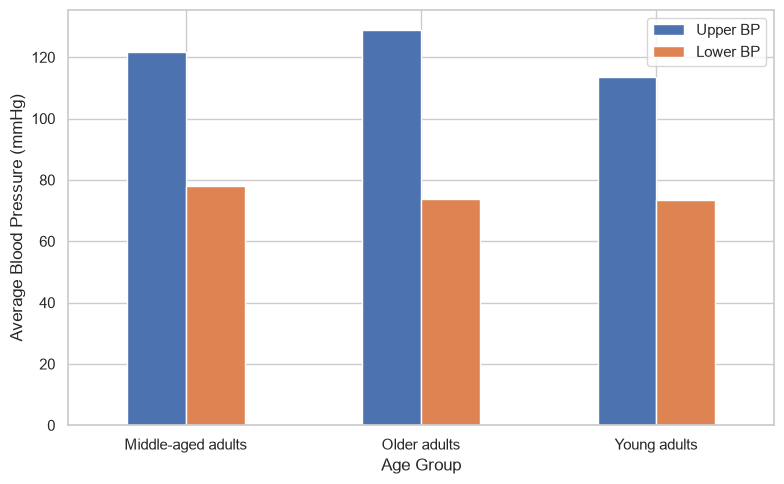

In [32]:
q1_plot = q1_result.set_index("age_group")

q1_plot[
    ["avg_upper_bp", "avg_lower_bp"]
].plot(kind="bar", figsize=(8, 5))

plt.xlabel("Age Group")
plt.ylabel("Average Blood Pressure (mmHg)")
#plt.title("Older Adults Have the Highest Average Blood Pressure")
plt.legend(["Upper BP", "Lower BP"])
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

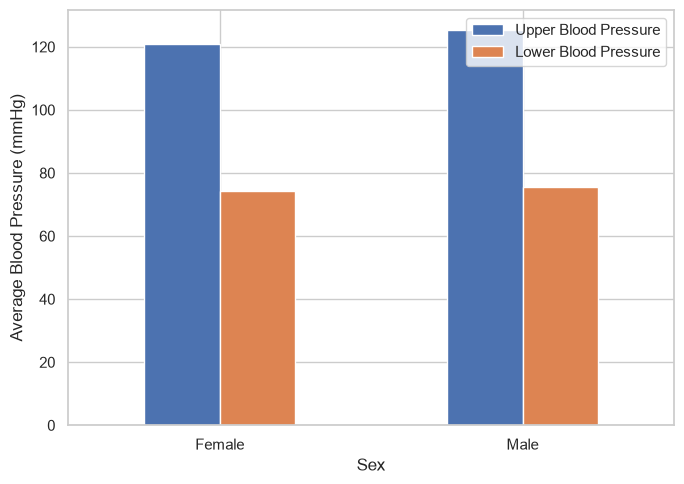

In [28]:
q2_plot = q2_result.set_index("sex")

q2_plot[
    ["avg_upper_bp", "avg_lower_bp"]
].plot(kind="bar", figsize=(7, 5))

highest_sex = q2_result.loc[
    q2_result["avg_upper_bp"].idxmax(),
    "sex"
]

plt.xlabel("Sex")
plt.ylabel("Average Blood Pressure (mmHg)")
plt.legend([
    "Upper Blood Pressure",
    "Lower Blood Pressure"
])
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

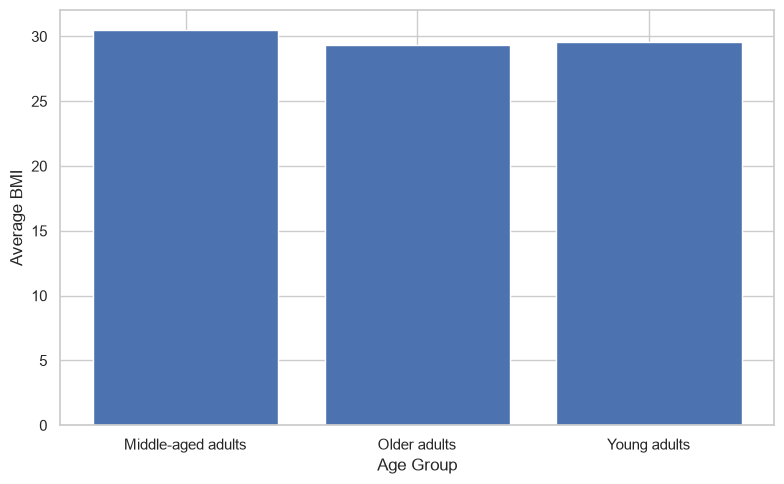

In [30]:
plt.figure(figsize=(8, 5))

plt.bar(
    q3_result["age_group"],
    q3_result["avg_bmi"]
)

highest_bmi_group = q3_result.loc[
    q3_result["avg_bmi"].idxmax(),
    "age_group"
]

plt.xlabel("Age Group")
plt.ylabel("Average BMI")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

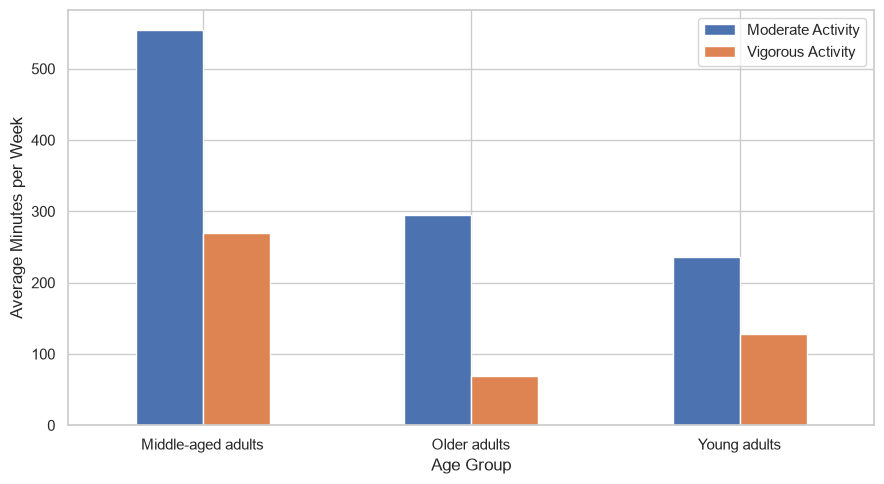

In [33]:
q4_plot = q4_result.set_index("age_group")

q4_plot[
    [
        "avg_moderate_minutes_week",
        "avg_vigorous_minutes_week"
    ]
].plot(kind="bar", figsize=(9, 5))

plt.xlabel("Age Group")
plt.ylabel("Average Minutes per Week")
plt.legend([
    "Moderate Activity",
    "Vigorous Activity"
])
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

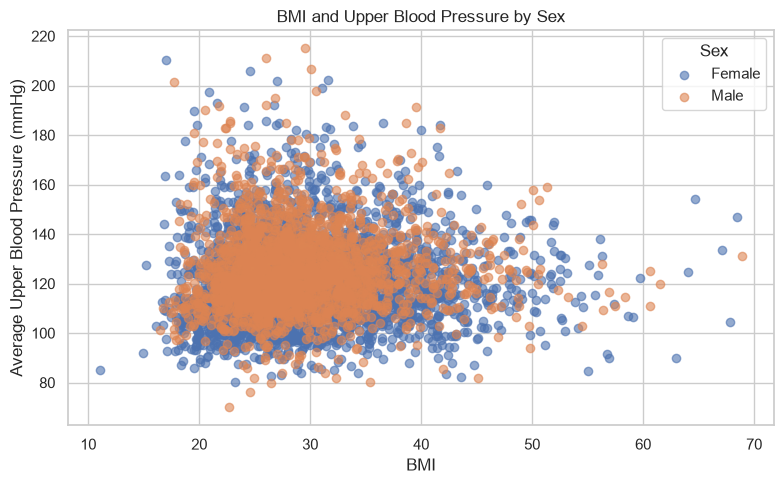

In [36]:
plt.figure(figsize=(8, 5))

for sex, group in q5_result.groupby("sex"):
    plt.scatter(
        group["bmi"],
        group["average_upper_bp"],
        label=sex,
        alpha=0.6
    )

plt.xlabel("BMI")
plt.ylabel("Average Upper Blood Pressure (mmHg)")
plt.title("BMI and Upper Blood Pressure by Sex")

plt.legend(title="Sex")
plt.tight_layout()
plt.show()

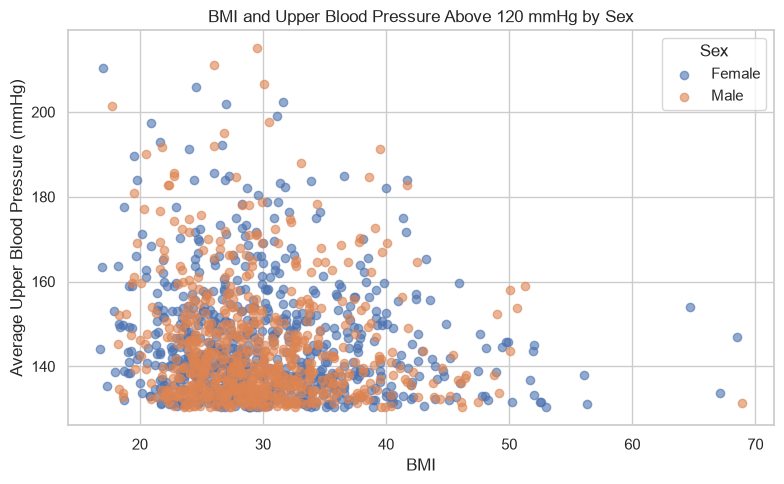

In [63]:
# Keep only participants with upper blood pressure > 120
q5_over_120 = q5_result[
    q5_result["average_upper_bp"] > 130
].copy()


plt.figure(figsize=(8, 5))

for sex, group in q5_over_120.groupby("sex"):
    plt.scatter(
        group["bmi"],
        group["average_upper_bp"],
        label=sex,
        alpha=0.6
    )

plt.xlabel("BMI")
plt.ylabel("Average Upper Blood Pressure (mmHg)")
plt.title("BMI and Upper Blood Pressure Above 120 mmHg by Sex")

plt.legend(title="Sex")
plt.tight_layout()
plt.show()

Rows before: 4849
Rows after outlier removal: 4719
Participants with upper BP > 120: 1249


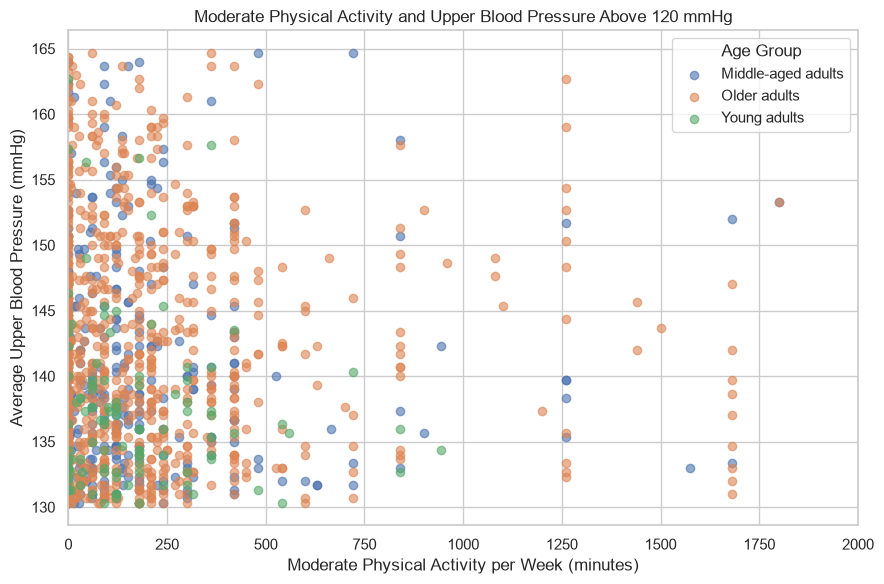

In [64]:

# 1. Remove outliers from upper blood pressure and moderate activity
q6_clean = remove_outliers_iqr(
    q6_result,
    [
        "average_upper_bp"
    ]
)

print("Rows before:", len(q6_result))
print("Rows after outlier removal:", len(q6_clean))


# 2. Keep only participants with upper blood pressure > 120
bp_over_120 = q6_clean[
    q6_clean["average_upper_bp"] > 130
].copy()

print("Participants with upper BP > 120:", len(bp_over_120))


# 3. Scatter plot
plt.figure(figsize=(9, 6))

for age_group, group in bp_over_120.groupby("age_group"):

    plt.scatter(
        group["moderate_minutes_per_week"],
        group["average_upper_bp"],
        label=age_group,
        alpha=0.6
    )

plt.xlabel("Moderate Physical Activity per Week (minutes)")
plt.ylabel("Average Upper Blood Pressure (mmHg)")

plt.title(
    "Moderate Physical Activity and Upper Blood Pressure Above 120 mmHg"
)

plt.legend(title="Age Group")
plt.xlim(0, 2000)
plt.tight_layout()
plt.show()

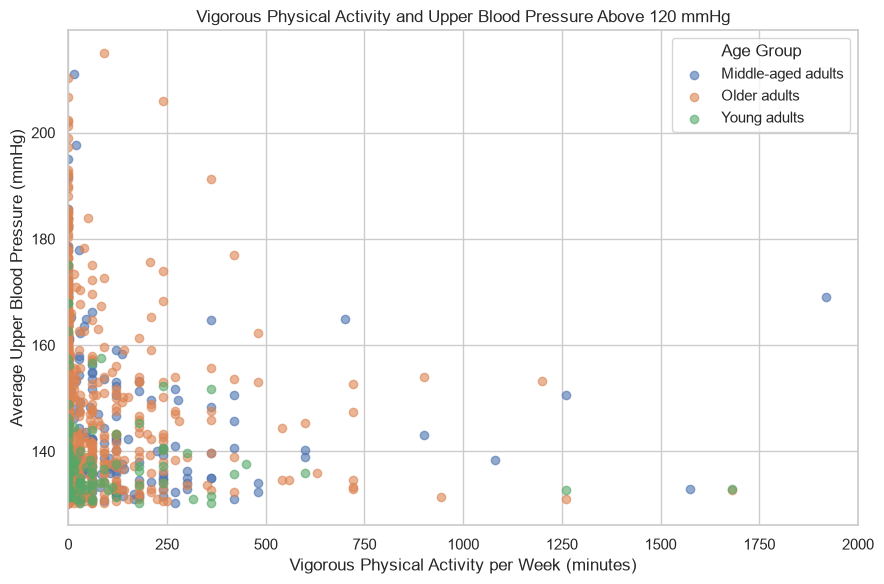

In [65]:

# Keep only participants with upper blood pressure above 120 mmHg
bp_over_120 = q6_result[
    q6_result["average_upper_bp"] > 130
].copy()

# Create scatter plot
plt.figure(figsize=(9, 6))

for age_group, group in bp_over_120.groupby("age_group"):
    plt.scatter(
        group["vigorous_minutes_per_week"],
        group["average_upper_bp"],
        label=age_group,
        alpha=0.6
    )

plt.xlabel("Vigorous Physical Activity per Week (minutes)")
plt.ylabel("Average Upper Blood Pressure (mmHg)")
plt.title(
    "Vigorous Physical Activity and Upper Blood Pressure Above 120 mmHg"
)

plt.legend(title="Age Group")
plt.xlim(0, 2000)
plt.tight_layout()
plt.show()

Rows before: 4849
Rows after BP outlier removal: 4719


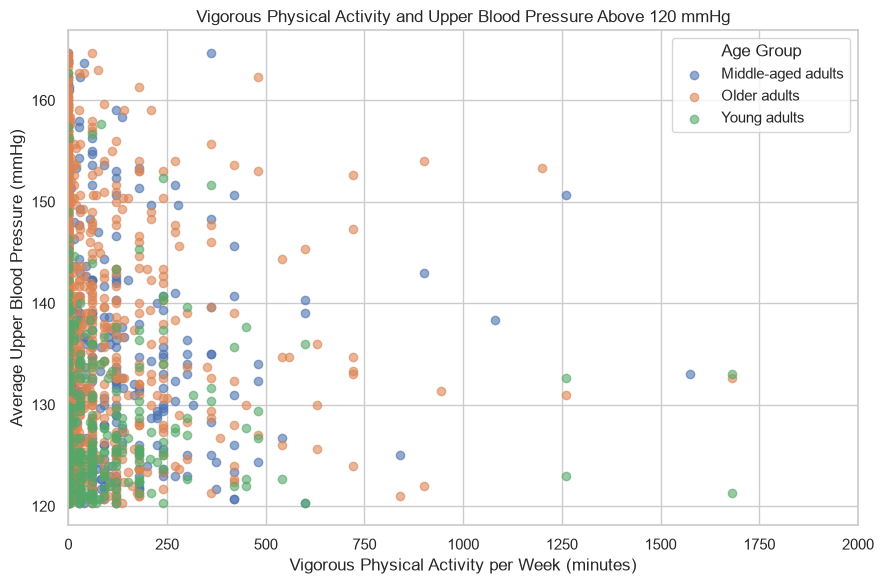

In [ ]:

# 1. Remove outliers only from upper blood pressure
q6_bp_clean = remove_outliers_iqr(
    q6_result,
    ["average_upper_bp"]
)

print("Rows before:", len(q6_result))
print("Rows after BP outlier removal:", len(q6_bp_clean))


# 2. Keep only participants with upper blood pressure > 120
bp_over_120 = q6_bp_clean[
    q6_bp_clean["average_upper_bp"] > 120
].copy()


# 3. Scatter plot: vigorous activity vs upper blood pressure
plt.figure(figsize=(9, 6))

for age_group, group in bp_over_120.groupby("age_group"):
    plt.scatter(
        group["vigorous_minutes_per_week"],
        group["average_upper_bp"],
        label=age_group,
        alpha=0.6
    )

plt.xlabel("Vigorous Physical Activity per Week (minutes)")
plt.ylabel("Average Upper Blood Pressure (mmHg)")
plt.title(
    "Vigorous Physical Activity and Upper Blood Pressure Above 120 mmHg"
)

plt.legend(title="Age Group")
plt.xlim(0, 2000)
plt.tight_layout()
plt.show()

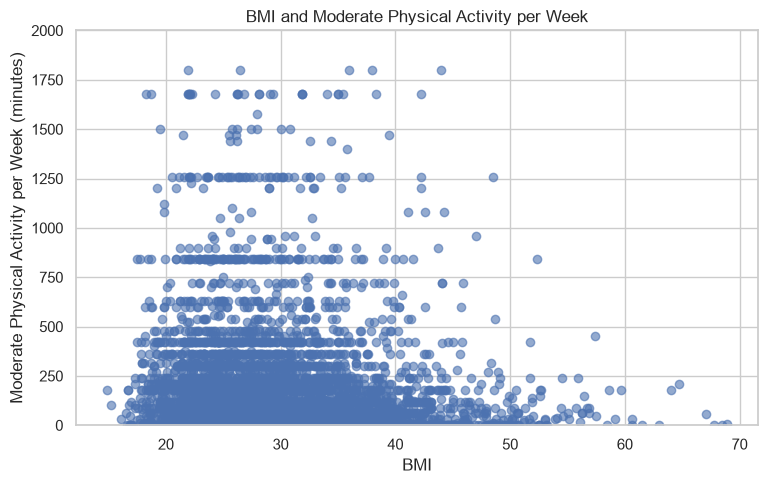

In [ ]:

plt.figure(figsize=(8, 5))

plt.scatter(
    q6_result["bmi"],
    q6_result["moderate_minutes_per_week"],
    alpha=0.6
)

plt.xlabel("BMI")
plt.ylabel("Moderate Physical Activity per Week (minutes)")
plt.title("BMI and Moderate Physical Activity per Week")

plt.tight_layout()
plt.ylim(0, 2000)
plt.show()

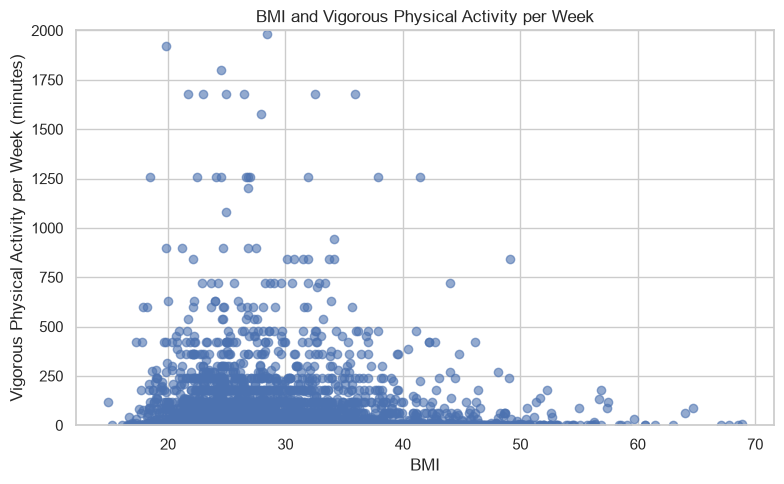

In [70]:

plt.figure(figsize=(8, 5))

plt.scatter(
    q6_result["bmi"],
    q6_result["vigorous_minutes_per_week"],
    alpha=0.6
)

plt.xlabel("BMI")
plt.ylabel("Vigorous Physical Activity per Week (minutes)")
plt.title("BMI and Vigorous Physical Activity per Week")

# Optional: only show 0–1000 minutes on the y-axis
plt.ylim(0, 2000)

plt.tight_layout()
plt.show()

---
## 5. Conclusions

Answer each question. Say whether your hypothesis held. Being wrong is a fine result, as long as you say so and show the evidence.

### Research Question 1  
**How does average blood pressure differ across age groups and sex?**

**Hypothesis:**  
Average blood pressure will differ across age groups and sex, with older adults expected to have higher average upper blood pressure.

**Answer:**  
The analysis showed differences in average blood pressure across age groups. The age-group bar plot showed that **Older Adults** had the highest average upper blood pressure, while **[Young Adult]** had the lowest.

When comparing males and females, **[males]** had a higher average upper blood pressure. The difference in lower blood pressure was **[small]**.


---
### Research Question 2  
**Among participants with upper blood pressure above 130 mmHg, what are their levels of moderate and vigorous physical activity?**

**Hypothesis:**  
Participants with upper blood pressure above 130 mmHg are expected to have relatively low levels of moderate and vigorous physical activity.

**Answer:**  
Participants with upper blood pressure above 130 mmHg were selected, and their weekly moderate and vigorous physical activity levels were examined.

The scatter plots showed how activity levels were distributed among participants with high upper blood pressure and how this distribution differed across age groups. Moderate physical activity showed **really mostly 0 minutes in week or very lower than 500 minutes mostly**, while vigorous physical activity showed **the same pattern but the number of zeros was much more**.

I could not find any pattern for age groups 

Therefore, the hypothesis was **[supported]**. Although some participants with high blood pressure reported high levels of physical activity. 

This is a descriptive analysis, so it shows the activity patterns of participants with high blood pressure but does not establish that low physical activity caused their high blood pressure.

---
## 6. Limitations and next steps

What this data cannot tell you, and what you would do with another week. Knowing the limits of your own analysis is part of the grade.

For the high-blood-pressure analysis, participants were selected using an upper blood pressure threshold above 130 mmHg. This was used as an analytical cutoff for exploring physical-activity patterns and should not be interpreted as a clinical diagnosis.

With additional time, the analysis could be extended by incorporating NHANES survey weights, examining other potential confounding variables such as age, BMI, income, and education, and using statistical models such as regression to investigate the relationships between physical activity, BMI, and blood pressure while adjusting for these factors. The analysis could also compare results using different blood-pressure thresholds and investigate moderate and vigorous physical activity separately in greater detail.